## Import libraries

In [1]:
import pandas as pd
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display_html
from scipy.optimize import least_squares
from scipy.interpolate import interp1d
from scipy.stats import poisson, nbinom

c:\Users\cicci\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Load data - exports

In [2]:
ROOT = Path.cwd().parent

data_path = ROOT / 'data'

In [3]:
df = pd.read_csv(data_path / 'dati_leo_assoluti.csv')
df = df.reset_index(drop=True)

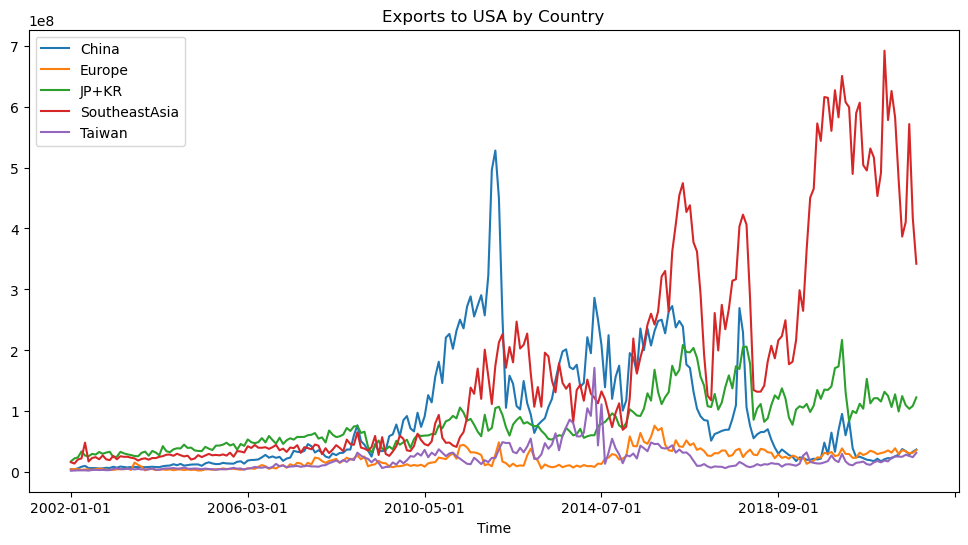

In [4]:
df.set_index('Time').plot(figsize=(12, 6), title='Exports to USA by Country')
plt.show()

## Model 2 - tariffs with true values

### Model

In [62]:
# Uncomment if you want normalized values
df_normalized = pd.read_csv(data_path / 'dati_leo_normalizzati.csv')
df_normalized = df_normalized.reset_index(drop=True)
df_normalized = df_normalized.drop(columns=['Europe', 'total'])
df_normalized

# # Uncomment if you want absolute values
#df_normalized = df.copy()
#df_normalized = df_normalized.drop(columns=['Europe'])
#df_normalized

,Time,China,JP+KR,SoutheastAsia,Taiwan
0,2002-01-01,0.110311,0.380993,0.352239,0.054684
1,2002-02-01,0.093534,0.454315,0.287546,0.057884
2,2002-03-01,0.107718,0.406185,0.349512,0.052608
3,2002-04-01,0.123506,0.467669,0.310324,0.044436
4,2002-05-01,0.110933,0.290828,0.515878,0.033958
...,...,...,...,...,...
235,2021-08-01,0.062298,0.204443,0.632360,0.041596
236,2021-09-01,0.055998,0.177974,0.663774,0.046366
237,2021-10-01,0.038418,0.136539,0.749306,0.035138
238,2021-11-01,0.054520,0.176605,0.676466,0.040333


In [63]:
df_normalized.head()

,Time,China,JP+KR,SoutheastAsia,Taiwan
0,2002-01-01,0.110311,0.380993,0.352239,0.054684
1,2002-02-01,0.093534,0.454315,0.287546,0.057884
2,2002-03-01,0.107718,0.406185,0.349512,0.052608
3,2002-04-01,0.123506,0.467669,0.310324,0.044436
4,2002-05-01,0.110933,0.290828,0.515878,0.033958


In [64]:
df_tariffs = pd.read_csv(data_path / 'tariffs_final.csv')
# convert values to int
df_tariffs['China Tariff'] = df_tariffs['China Tariff'].astype(float)
df_tariffs['JP+KR Tariff'] = df_tariffs['JP+KR Tariff'].astype(float)
df_tariffs['SoutheastAsia Tariff'] = df_tariffs['SoutheastAsia Tariff'].astype(float)
df_tariffs['Taiwan Tariff'] = df_tariffs['Taiwan Tariff'].astype(float)
df_tariffs

,Time,China Tariff,JP+KR Tariff,SoutheastAsia Tariff,Taiwan Tariff
0,2002-01-01,0.00,0.00,0.00,0.00
1,2002-02-01,0.00,0.00,0.00,0.00
2,2002-03-01,0.00,0.00,0.00,0.00
3,2002-04-01,0.00,0.00,0.00,0.00
4,2002-05-01,0.00,0.00,0.00,0.00
...,...,...,...,...,...
235,2021-08-01,0.15,0.15,0.15,0.15
236,2021-09-01,0.15,0.15,0.15,0.15
237,2021-10-01,0.15,0.15,0.15,0.15
238,2021-11-01,0.15,0.15,0.15,0.15


In [65]:
def lotka_volterra_with_tariffs_substitution(t, X, tariffs,
                                             r1, r2, r3, r4,
                                             a11, a12, a13, a14,
                                             a21, a22, a23, a24,
                                             a31, a32, a33, a34,
                                             a41, a42, a43, a44,
                                             b12, b13, b14,
                                             b21, b23, b24,
                                             b31, b32, b34,
                                             b41, b42, b43,
                                             s12, s13, s14,  # gains to X1 from others' tariffs
                                             s21, s23, s24,
                                             s31, s32, s34,
                                             s41, s42, s43):  # gains to X4 from others' tariffs
    X1, X2, X3, X4 = X
    tariff_1, tariff_2, tariff_3, tariff_4 = tariffs.iloc[int(t), 1:]

    dx1dt = r1 * X1 * (1 - (
        a11*X1 + (1 + b12*tariff_1)*a12*X2 + (1 + b13*tariff_1)*a13*X3 + (1 + b14*tariff_1)*a14*X4
    )) + s12*tariff_2 + s13*tariff_3 + s14*tariff_4

    dx2dt = r2 * X2 * (1 - (
        a22*X2 + (1 + b21*tariff_2)*a21*X1 + (1 + b23*tariff_2)*a23*X3 + (1 + b24*tariff_2)*a24*X4
    )) + s21*tariff_1 + s23*tariff_3 + s24*tariff_4

    dx3dt = r3 * X3 * (1 - (
        a33*X3 + (1 + b31*tariff_3)*a31*X1 + (1 + b32*tariff_3)*a32*X2 + (1 + b34*tariff_3)*a34*X4
    )) + s31*tariff_1 + s32*tariff_2 + s34*tariff_4

    dx4dt = r4 * X4 * (1 - (
        a44*X4 + (1 + b41*tariff_4)*a41*X1 + (1 + b42*tariff_4)*a42*X2 + (1 + b43*tariff_4)*a43*X3
    )) + s41*tariff_1 + s42*tariff_2 + s43*tariff_3

    return [dx1dt, dx2dt, dx3dt, dx4dt]


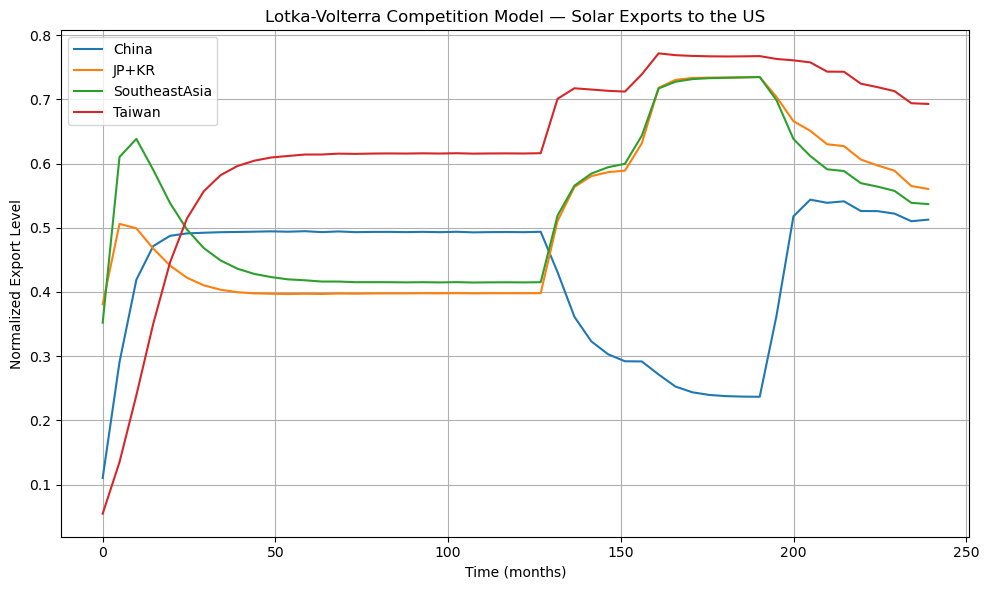

In [66]:
# Uncomment to use parameters for normalized values
params = {
    # Growth rates
    'r1': 0.5, 'r2': 0.3, 'r3': 0.4, 'r4': 0.35,

    # Competition coefficients (a_ij)
    'a11': 1.0, 'a12': 0.6, 'a13': 0.2, 'a14': 0.3,
    'a21': 0.3, 'a22': 1.0, 'a23': 0.5, 'a24': 0.4,
    'a31': 0.4, 'a32': 0.2, 'a33': 1.0, 'a34': 0.5,
    'a41': 0.2, 'a42': 0.3, 'a43': 0.4, 'a44': 1.0,

    # Tariff penalty coefficients (b_ij)
    'b12': 0.1, 'b13': 0.1, 'b14': 0.1,
    'b21': 0.1, 'b23': 0.1, 'b24': 0.1,
    'b31': 0.1, 'b32': 0.1, 'b34': 0.1,
    'b41': 0.1, 'b42': 0.1, 'b43': 0.1,

    # Substitution boost coefficients (s_ij)
    's12': 0.1, 's13': 0.1, 's14': 0.1,
    's21': 0.1, 's23': 0.1, 's24': 0.1,
    's31': 0.1, 's32': 0.1, 's34': 0.1,
    's41': 0.1, 's42': 0.1, 's43': 0.1
}



# # Uncomment to use parameters for absolute values
# params = {
#     'r1': 50.0, 'r2': 30.0, 'r3': 40.0, 'r4': 35.0,
#     'a11': 0.00001, 'a12': 0.000006, 'a13': 0.000004, 'a14': 0.000003,
#     'a21': 0.000004, 'a22': 0.000002, 'a23': 0.000003, 'a24': 0.000004,
#     'a31': 0.000004, 'a32': 0.000002, 'a33': 0.000003, 'a34': 0.000005,
#     'a41': 0.000006, 'a42': 0.000004, 'a43': 0.000004, 'a44': 0.00001,
#     'b1': 0.000001, 'b2': 0.000001, 'b3': 0.000001, 'b4': 0.000001
# }


# Initial conditions (example, adjust as needed)
X0 = df_normalized.iloc[0, 1:].values.tolist()  # Use the first row of normalized data as initial conditions

# Time span and evaluation points
t_span = (0, 239)
t_eval = np.linspace(*t_span)

# Solve the system
sol = solve_ivp(
    fun=lambda t, X: lotka_volterra_with_tariffs_substitution(t, X, df_tariffs, **params),
    t_span=t_span,
    y0=X0,
    t_eval=t_eval
)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(sol.t, sol.y[0], label='China')
plt.plot(sol.t, sol.y[1], label='JP+KR')
plt.plot(sol.t, sol.y[2], label='SoutheastAsia')
plt.plot(sol.t, sol.y[3], label='Taiwan')
plt.title('Lotka-Volterra Competition Model — Solar Exports to the US')
plt.xlabel('Time (months)')
plt.ylabel('Normalized Export Level')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [67]:
sol

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  4.878e+00 ...  2.341e+02  2.390e+02]
        y: [[ 1.103e-01  2.910e-01 ...  5.103e-01  5.127e-01]
            [ 3.810e-01  5.061e-01 ...  5.650e-01  5.605e-01]
            [ 3.522e-01  6.103e-01 ...  5.389e-01  5.369e-01]
            [ 5.468e-02  1.351e-01 ...  6.940e-01  6.929e-01]]
      sol: None
 t_events: None
 y_events: None
     nfev: 398
     njev: 0
      nlu: 0

### Model Calibration - Least Squares

In [68]:
china_data = df_normalized['China']
jpkr_data = df_normalized['JP+KR']
southeastasia_data = df_normalized['SoutheastAsia']
taiwan_data = df_normalized['Taiwan']

# Stack data for comparison
data = np.vstack([china_data, jpkr_data, southeastasia_data, taiwan_data])  # shape (4, T)
t_data = np.linspace(0, len(china_data)-1, len(china_data))  # e.g. months

In [69]:
def residuals(params, X0, tariffs, t_data, data):
    # Unpack parameters
    r1, r2, r3, r4 = params[:4]

    a11, a12, a13, a14 = params[4:8]
    a21, a22, a23, a24 = params[8:12]
    a31, a32, a33, a34 = params[12:16]
    a41, a42, a43, a44 = params[16:20]

    b12, b13, b14 = params[20:23]
    b21, b23, b24 = params[23:26]
    b31, b32, b34 = params[26:29]
    b41, b42, b43 = params[29:32]

    s12, s13, s14 = params[32:35]
    s21, s23, s24 = params[35:38]
    s31, s32, s34 = params[38:41]
    s41, s42, s43 = params[41:44]

    sol = solve_ivp(
        fun=lambda t, X: lotka_volterra_with_tariffs_substitution(
            t, X, tariffs,
            r1, r2, r3, r4,
            a11, a12, a13, a14,
            a21, a22, a23, a24,
            a31, a32, a33, a34,
            a41, a42, a43, a44,
            b12, b13, b14,
            b21, b23, b24,
            b31, b32, b34,
            b41, b42, b43,
            s12, s13, s14,
            s21, s23, s24,
            s31, s32, s34,
            s41, s42, s43,
        ),
        t_span=(t_data[0], t_data[-1]),
        y0=X0,
        t_eval=t_data,
        method='RK45'
    )

    if sol.y.shape[1] != len(t_data):
        return np.ones(data.size) * 1e6  # Large penalty if ODE fails

    return (sol.y - data).ravel()


In [70]:
initial_guess = [
    # Growth rates
    params['r1'], params['r2'], params['r3'], params['r4'],

    # Competition coefficients
    params['a11'], params['a12'], params['a13'], params['a14'],
    params['a21'], params['a22'], params['a23'], params['a24'],
    params['a31'], params['a32'], params['a33'], params['a34'],
    params['a41'], params['a42'], params['a43'], params['a44'],

    # Tariff penalties
    params['b12'], params['b13'], params['b14'],
    params['b21'], params['b23'], params['b24'],
    params['b31'], params['b32'], params['b34'],
    params['b41'], params['b42'], params['b43'],

    # Substitution boosts
    params['s12'], params['s13'], params['s14'],
    params['s21'], params['s23'], params['s24'],
    params['s31'], params['s32'], params['s34'],
    params['s41'], params['s42'], params['s43'],
    # Carrying capacities
]


In [71]:
# Initial export levels from your data
X0 = data[:, 0]

# Fit the model
result = least_squares(
	residuals,
	initial_guess,
	args=(X0, df_tariffs, t_data, data),
	bounds=(0, np.inf)  # constrain params to be positive
)

# Extract best-fit parameters
fitted_params = result.x

In [72]:
fitted_params

array([6.22780445e-01, 5.64667810e-01, 3.25863016e-01, 4.00361550e-01,
       1.21391551e+00, 1.08147543e+00, 1.08251014e+00, 2.03243014e-03,
       4.35718913e-02, 8.42681439e-01, 1.33740867e+00, 2.98150183e+00,
       3.28295510e-02, 6.61441261e-01, 1.73014454e+00, 2.46456613e+00,
       3.95005997e-01, 3.52723555e-01, 2.12838952e+00, 1.29602588e+00,
       4.11544197e-04, 7.29164577e-02, 6.14880514e-02, 1.11468099e-01,
       1.07725220e+00, 1.30397846e+00, 7.96994382e-02, 1.86833614e-01,
       1.03945802e+00, 2.48129002e-01, 7.59268907e-01, 1.11119824e+00,
       1.62865689e-02, 1.62865704e-02, 6.80767604e-04, 2.32119187e-02,
       1.48088116e-01, 6.87233199e-02, 3.59251580e-02, 3.68907265e-01,
       7.85134398e-02, 2.53429878e-02, 2.47660041e-02, 2.47649690e-02])

In [73]:
t_data = np.linspace(0, len(china_data)-1, len(china_data))  # e.g. months
sol = solve_ivp(
    fun=lambda t, X: lotka_volterra_with_tariffs_substitution(t, X, df_tariffs, *fitted_params),
    t_span=(t_data[0], t_data[-1]),
    y0=X0,
    t_eval=t_data
)

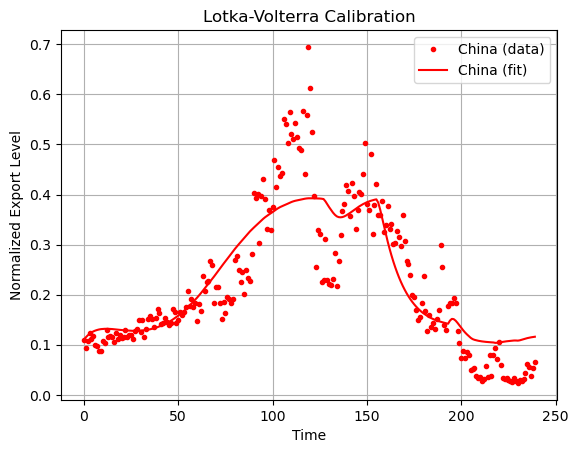

In [74]:
# Plot
plt.plot(t_data[:len(data[0])], data[0], 'r.', label='China (data)')
plt.plot(t_data, sol.y[0], 'r-', label='China (fit)')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Normalized Export Level')
plt.title('Lotka-Volterra Calibration')
plt.grid(True)
plt.show()

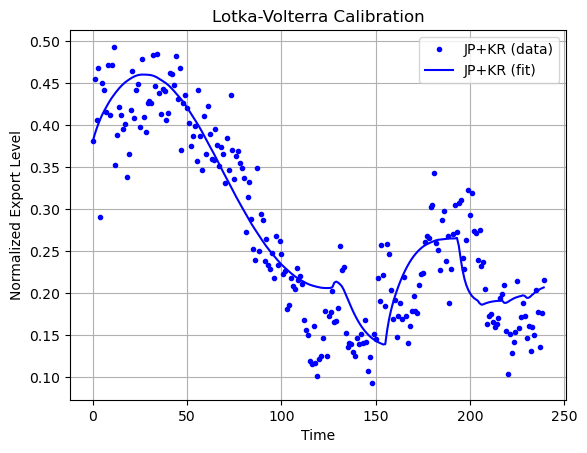

In [75]:
plt.plot(t_data[:len(data[1])], data[1], 'b.', label='JP+KR (data)')
plt.plot(t_data, sol.y[1], 'b-', label='JP+KR (fit)')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Normalized Export Level')
plt.title('Lotka-Volterra Calibration')
plt.grid(True)
plt.show()

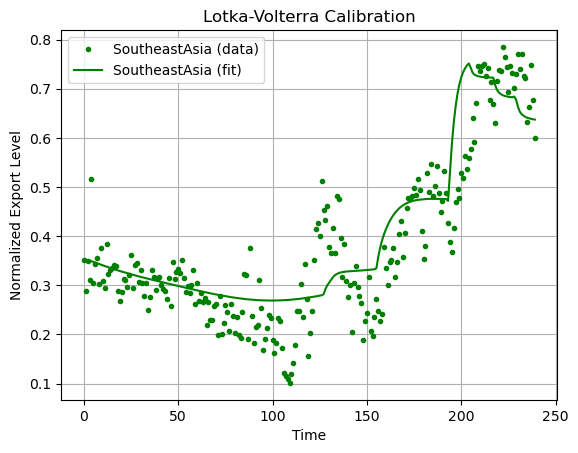

In [76]:
plt.plot(t_data[:len(data[2])], data[2], 'g.', label='SoutheastAsia (data)')
plt.plot(t_data, sol.y[2], 'g-', label='SoutheastAsia (fit)')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Normalized Export Level')
plt.title('Lotka-Volterra Calibration')
plt.grid(True)
plt.show()

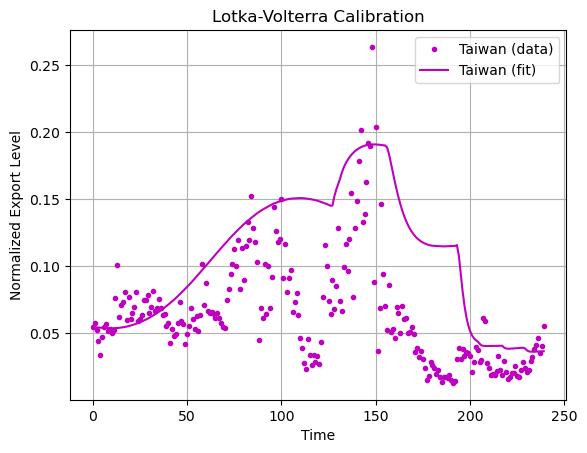

In [77]:
plt.plot(t_data[:len(data[3])], data[3], 'm.', label='Taiwan (data)')
plt.plot(t_data, sol.y[3], 'm-', label='Taiwan (fit)')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Normalized Export Level')
plt.title('Lotka-Volterra Calibration')
plt.grid(True)
plt.show()

### Prediction

In [33]:
df_tariffs_pred = pd.concat([df_tariffs.copy(), pd.DataFrame(np.zeros([240, 4]), columns=['China Tariff', 'JP+KR Tariff', 'SoutheastAsia Tariff', 'Taiwan Tariff'])], axis=0)
df_tariffs_pred = df_tariffs_pred.reset_index(drop=True)
df_tariffs_pred['Time'] = pd.date_range(start='2002-01-01', periods=len(df_tariffs_pred), freq='MS')
df_tariffs_pred

,Time,China Tariff,JP+KR Tariff,SoutheastAsia Tariff,Taiwan Tariff
0,2002-01-01,0.0,0.0,0.0,0.0
1,2002-02-01,0.0,0.0,0.0,0.0
2,2002-03-01,0.0,0.0,0.0,0.0
3,2002-04-01,0.0,0.0,0.0,0.0
4,2002-05-01,0.0,0.0,0.0,0.0
...,...,...,...,...,...
475,2041-08-01,0.0,0.0,0.0,0.0
476,2041-09-01,0.0,0.0,0.0,0.0
477,2041-10-01,0.0,0.0,0.0,0.0
478,2041-11-01,0.0,0.0,0.0,0.0


In [34]:
df_tariffs_pred['China Tariff'] = np.where(df_tariffs_pred['Time'] < '2026-05-01', 0, 1)
df_tariffs_pred['JP+KR Tariff'] = np.where(df_tariffs_pred['Time'] < '2028-02-01', 0, 1)
df_tariffs_pred['SoutheastAsia Tariff'] = np.where(df_tariffs_pred['Time'] < '2023-02-01', 0, 1)
df_tariffs_pred['Taiwan Tariff'] = np.where(df_tariffs_pred['Time'] < '2025-12-01', 0, 1)
df_tariffs_pred

,Time,China Tariff,JP+KR Tariff,SoutheastAsia Tariff,Taiwan Tariff
0,2002-01-01,0,0,0,0
1,2002-02-01,0,0,0,0
2,2002-03-01,0,0,0,0
3,2002-04-01,0,0,0,0
4,2002-05-01,0,0,0,0
...,...,...,...,...,...
475,2041-08-01,1,1,1,1
476,2041-09-01,1,1,1,1
477,2041-10-01,1,1,1,1
478,2041-11-01,1,1,1,1


In [35]:
sol = solve_ivp(
    fun=lambda t, X: lotka_volterra_with_tariffs_substitution(t, X, df_tariffs_pred, *fitted_params),
    t_span=(0, len(df_tariffs_pred) - 1),
    y0=X0,
    t_eval=np.arange(len(df_tariffs_pred))
)

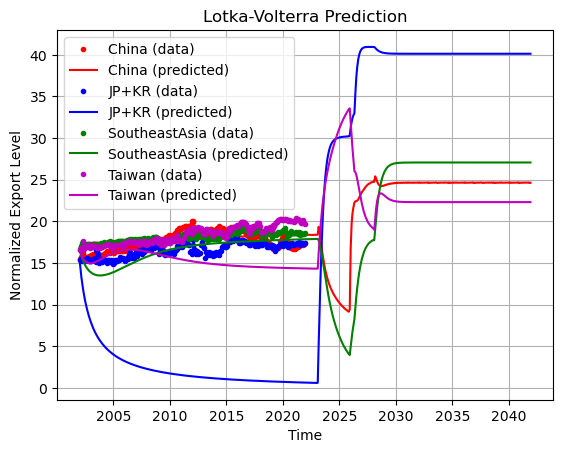

In [36]:
# Plot
plt.plot(df_tariffs_pred['Time'][:len(data[0])], data[0], 'r.', label='China (data)')
plt.plot(df_tariffs_pred['Time'], sol.y[0], 'r-', label='China (predicted)')
plt.plot(df_tariffs_pred['Time'][:len(data[1])], data[1], 'b.', label='JP+KR (data)')
plt.plot(df_tariffs_pred['Time'], sol.y[1], 'b-', label='JP+KR (predicted)')
plt.plot(df_tariffs_pred['Time'][:len(data[2])], data[2], 'g.', label='SoutheastAsia (data)')
plt.plot(df_tariffs_pred['Time'], sol.y[2], 'g-', label='SoutheastAsia (predicted)')
plt.plot(df_tariffs_pred['Time'][:len(data[3])], data[3], 'm.', label='Taiwan (data)')
plt.plot(df_tariffs_pred['Time'], sol.y[3], 'm-', label='Taiwan (predicted)')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Normalized Export Level')
plt.title('Lotka-Volterra Prediction')
plt.grid(True)
plt.show()